# Monthly KPI Analysis

## 목적

Olist의 최근 완전 12개월 Item Sales 변화를 확인하고,
변화를 Buyer Count, Orders per Buyer,
Average Item Sales per Order로 분해한다.

## 분석 기간

2017-09-01 이상
2018-09-01 미만

## 대상

order_status = delivered

## 핵심 KPI

- Item Sales
- Order Count
- Buyer Count
- Orders per Buyer
- Average Item Sales per Order
- Monthly Growth

In [1]:
from pathlib import Path

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
project_root = Path.cwd().parent

database_path = (
    project_root
    / "data"
    / "processed"
    / "olist.db"
)

report_dir = (
    project_root
    / "reports"
)

figure_dir = (
    report_dir
    / "figures"
)

figure_dir.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
connection = sqlite3.connect(
    database_path
)

In [4]:
monthly_kpi_df = pd.read_sql_query(
    """
    SELECT
        order_month,

        sum(
            item_sales
        ) AS item_sales,

        count(*) AS order_count,

        count(
            DISTINCT customer_unique_id
        ) AS buyer_count,

        sum(
            item_sales
        ) * 1.0
        / count(*) AS average_item_sales_per_order,

        count(*) * 1.0
        / count(
            DISTINCT customer_unique_id
        ) AS orders_per_buyer

    FROM analysis_orders

    GROUP BY
        order_month

    ORDER BY
        order_month
    """,
    connection
)

print(
    monthly_kpi_df
)

   order_month  item_sales  order_count  buyer_count  \
0      2017-09   607399.67         4150         4083   
1      2017-10   648247.65         4478         4417   
2      2017-11   987765.37         7289         7183   
3      2017-12   726033.19         5513         5450   
4      2018-01   924645.00         7069         6974   
5      2018-02   826437.13         6555         6400   
6      2018-03   953356.25         7003         6914   
7      2018-04   973534.09         6798         6744   
8      2018-05   977544.69         6749         6693   
9      2018-06   856077.86         6099         6061   
10     2018-07   867953.46         6159         6100   
11     2018-08   838576.64         6351         6310   

    average_item_sales_per_order  orders_per_buyer  
0                     146.361366          1.016410  
1                     144.762762          1.013810  
2                     135.514525          1.014757  
3                     131.694756          1.011560  
4     

In [5]:
print(
    monthly_kpi_df.shape
)

print(
    monthly_kpi_df.dtypes
)

print(
    monthly_kpi_df.isna().sum()
)

(12, 6)
order_month                         str
item_sales                      float64
order_count                       int64
buyer_count                       int64
average_item_sales_per_order    float64
orders_per_buyer                float64
dtype: object
order_month                     0
item_sales                      0
order_count                     0
buyer_count                     0
average_item_sales_per_order    0
orders_per_buyer                0
dtype: int64


In [6]:
# KPI 성장률 계산
monthly_kpi_df["item_sales_growth"] = (
    monthly_kpi_df["item_sales"]
    .pct_change()
)

monthly_kpi_df["buyer_count_growth"] = (
    monthly_kpi_df["buyer_count"]
    .pct_change()
)

monthly_kpi_df["orders_per_buyer_growth"] = (
    monthly_kpi_df["orders_per_buyer"]
    .pct_change()
)

monthly_kpi_df[
    "average_item_sales_per_order_growth"
] = (
    monthly_kpi_df[
        "average_item_sales_per_order"
    ]
    .pct_change()
)

In [7]:
print(
    monthly_kpi_df[
        [
            "order_month",
            "item_sales",
            "item_sales_growth",
            "buyer_count_growth",
            "orders_per_buyer_growth",
            "average_item_sales_per_order_growth"
        ]
    ].round(3)
)

   order_month  item_sales  item_sales_growth  buyer_count_growth  \
0      2017-09   607399.67                NaN                 NaN   
1      2017-10   648247.65              0.067               0.082   
2      2017-11   987765.37              0.524               0.626   
3      2017-12   726033.19             -0.265              -0.241   
4      2018-01   924645.00              0.274               0.280   
5      2018-02   826437.13             -0.106              -0.082   
6      2018-03   953356.25              0.154               0.080   
7      2018-04   973534.09              0.021              -0.025   
8      2018-05   977544.69              0.004              -0.008   
9      2018-06   856077.86             -0.124              -0.094   
10     2018-07   867953.46              0.014               0.006   
11     2018-08   838576.64             -0.034               0.034   

    orders_per_buyer_growth  average_item_sales_per_order_growth  
0                       NaN        

In [8]:
# KPI 분해식 확인
monthly_kpi_df["reconstructed_item_sales"] = (
    monthly_kpi_df["buyer_count"]
    * monthly_kpi_df["orders_per_buyer"]
    * monthly_kpi_df[
        "average_item_sales_per_order"
    ]
)

monthly_kpi_df["reconstruction_difference"] = (
    monthly_kpi_df["item_sales"]
    - monthly_kpi_df[
        "reconstructed_item_sales"
    ]
)

print(
    monthly_kpi_df[
        [
            "order_month",
            "item_sales",
            "reconstructed_item_sales",
            "reconstruction_difference"
        ]
    ].round(3)
)

   order_month  item_sales  reconstructed_item_sales  \
0      2017-09   607399.67                 607399.67   
1      2017-10   648247.65                 648247.65   
2      2017-11   987765.37                 987765.37   
3      2017-12   726033.19                 726033.19   
4      2018-01   924645.00                 924645.00   
5      2018-02   826437.13                 826437.13   
6      2018-03   953356.25                 953356.25   
7      2018-04   973534.09                 973534.09   
8      2018-05   977544.69                 977544.69   
9      2018-06   856077.86                 856077.86   
10     2018-07   867953.46                 867953.46   
11     2018-08   838576.64                 838576.64   

    reconstruction_difference  
0                         0.0  
1                         0.0  
2                         0.0  
3                        -0.0  
4                         0.0  
5                         0.0  
6                         0.0  
7              

In [9]:
# 가장 많이 증가한 달
sales_growth_top_df = (
    monthly_kpi_df[
        monthly_kpi_df["item_sales_growth"]
        .notna()
    ]
    .sort_values(
        "item_sales_growth",
        ascending = False
    )
)

print(
    sales_growth_top_df[
        [
            "order_month",
            "item_sales_growth",
            "buyer_count_growth",
            "orders_per_buyer_growth",
            "average_item_sales_per_order_growth"
        ]
    ]
    .head(3)
    .round(3)
)

  order_month  item_sales_growth  buyer_count_growth  orders_per_buyer_growth  \
2     2017-11              0.524               0.626                    0.001   
4     2018-01              0.274               0.280                    0.002   
6     2018-03              0.154               0.080                   -0.011   

   average_item_sales_per_order_growth  
2                               -0.064  
4                               -0.007  
6                                0.080  


In [10]:
# 가장 많이 감소한 달
sales_growth_bottom_df = (
    monthly_kpi_df[
        monthly_kpi_df["item_sales_growth"]
        .notna()
    ]
    .sort_values(
        "item_sales_growth"
    )
)

print(
    sales_growth_bottom_df[
        [
            "order_month",
            "item_sales_growth",
            "buyer_count_growth",
            "orders_per_buyer_growth",
            "average_item_sales_per_order_growth"
        ]
    ]
    .head(3)
    .round(3)
)

  order_month  item_sales_growth  buyer_count_growth  orders_per_buyer_growth  \
3     2017-12             -0.265              -0.241                   -0.003   
9     2018-06             -0.124              -0.094                   -0.002   
5     2018-02             -0.106              -0.082                    0.010   

   average_item_sales_per_order_growth  
3                               -0.028  
9                               -0.031  
5                               -0.036  


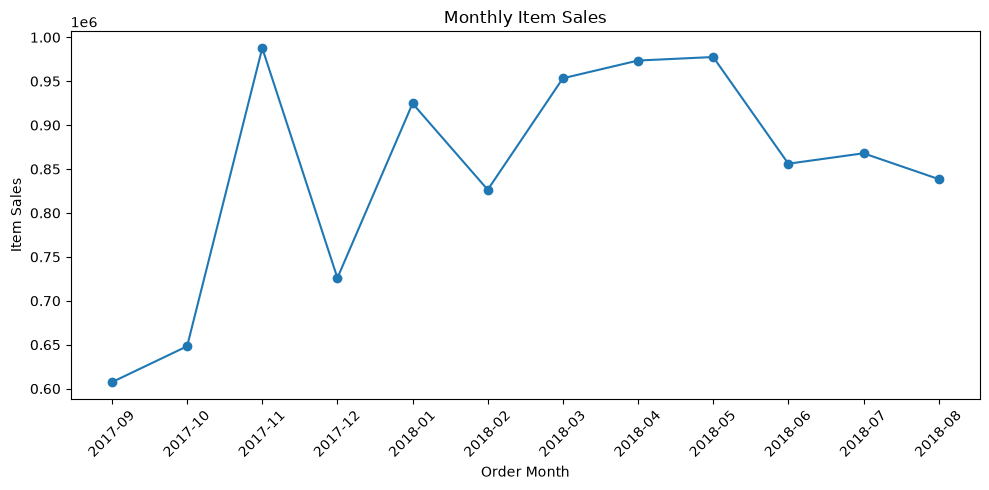

In [11]:
# 월별 Item Sales 그래프
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    monthly_kpi_df["order_month"],
    monthly_kpi_df["item_sales"],
    marker="o"
)

ax.set_title(
    "Monthly Item Sales"
)

ax.set_xlabel(
    "Order Month"
)

ax.set_ylabel(
    "Item Sales"
)

ax.tick_params(
    axis="x",
    rotation=45
)

fig.tight_layout()

fig.savefig(
    figure_dir
    / "monthly_item_sales.png",
    dpi=150
)

plt.show()

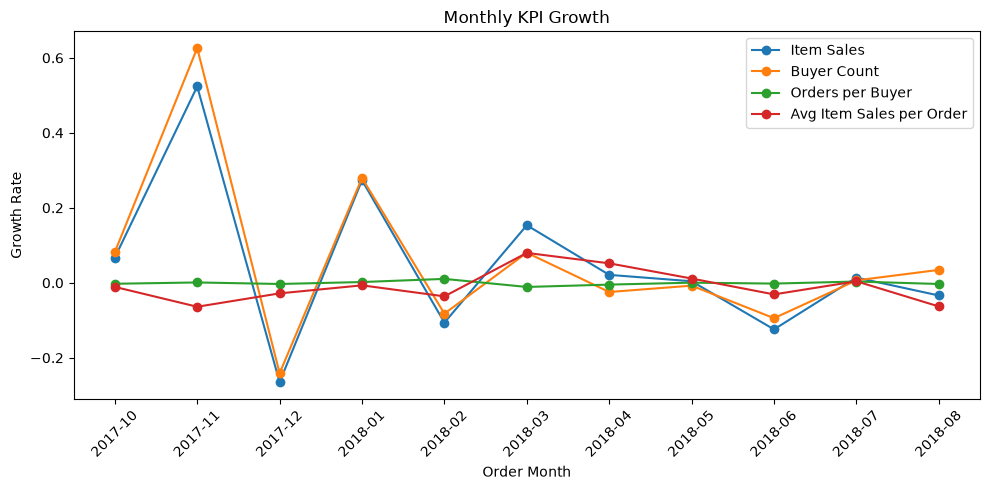

In [12]:
# 성장률 비교 그래프
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    monthly_kpi_df["order_month"],
    monthly_kpi_df["item_sales_growth"],
    marker="o",
    label="Item Sales"
)

ax.plot(
    monthly_kpi_df["order_month"],
    monthly_kpi_df["buyer_count_growth"],
    marker="o",
    label="Buyer Count"
)

ax.plot(
    monthly_kpi_df["order_month"],
    monthly_kpi_df["orders_per_buyer_growth"],
    marker="o",
    label="Orders per Buyer"
)

ax.plot(
    monthly_kpi_df["order_month"],
    monthly_kpi_df[
        "average_item_sales_per_order_growth"
    ],
    marker="o",
    label="Avg Item Sales per Order"
)

ax.set_title(
    "Monthly KPI Growth"
)

ax.set_xlabel(
    "Order Month"
)

ax.set_ylabel(
    "Growth Rate"
)

ax.tick_params(
    axis="x",
    rotation=45
)

ax.legend()

fig.tight_layout()

fig.savefig(
    figure_dir
    / "monthly_kpi_growth.png",
    dpi=150
)

plt.show()

In [13]:
monthly_kpi_path = (
    report_dir
    / "monthly_kpi.csv"
)

monthly_kpi_df.to_csv(
    monthly_kpi_path,
    index=False
)

In [14]:
connection.close()

## Analysis Results

### 분석 범위

- 기간: 2017-09 ~ 2018-08
- 주문 상태: delivered
- 고객 식별자: customer_unique_id
- 판매금액: Item Sales = SUM(price)

### 월별 Item Sales

- 가장 높은 월: 2017-11
- 가장 낮은 월: 2017-09
- 가장 큰 전월 대비 증가: 52.4%
- 가장 큰 전월 대비 감소: -26.5%

### 증가 구간 분석

Item Sales가 가장 크게 증가한 월에는:

- Buyer Count: 62.6%
- Orders per Buyer: 0.1%
- Average Item Sales per Order: -6.4%

가 각각 변화했다.

따라서 해당 월의 Item Sales 증가는
Buyer Count 변화와 가장 강하게 함께 나타났다.

### 감소 구간 분석

Item Sales가 가장 크게 감소한 월에는:

- Buyer Count: -24.1%
- Orders per Buyer: -0.3%
- Average Item Sales per Order: -2.8%

가 각각 변화했다.

따라서 해당 월의 Item Sales 감소는
Buyer Count 변화와 가장 강하게 함께 나타났다.

### 주의점

이 분석은 Item Sales 변화를 구성 KPI로 분해한 것이다.

고객 수나 주문당 판매금액의 변화가
프로모션, 계절성 또는 외부 환경 때문에 발생했는지는
현재 데이터만으로 인과적으로 판단할 수 없다.